# MCDI504 - Machine Learning I
## Evaluación Formativa - Fase 2: Modelos de regresión supervisada

**Caso:** California Housing - predicción del valor mediano de viviendas  
**Dataset:** California Housing (`sklearn.datasets.fetch_california_housing`)  
**Variable objetivo:** `MedHouseVal`  
**Integrantes:** Enzo Pinilla, Claudio Alarcón y Luis Rodrigo Espinoza  
**Docente:** David Ruete Zúñiga  
**Grupo:** 2  
**Fecha:** 16-08-2026  
**Repositorio del grupo:** `MCDI504_MACHINE_LEARNING_1_GRUPO_2`

## 0. Reproducibilidad del entorno

Se fija una única semilla aleatoria (`RANDOM_STATE = 42`), reutilizada en la partición de datos y en todos los modelos con componente estocástica (Árbol de Decisión, Random Forest, MLP). Esto permite que los resultados de este notebook sean replicables ejecutando `Restart Kernel + Run All` desde cero, sin depender de variables creadas manualmente ni de ejecución fuera de orden.
Las figuras se muestran dentro del notebook y también se guardan automáticamente en `figures/fase2_regresion/`.


In [1]:
from pathlib import Path
import platform
import numpy as np
import pandas as pd
import sklearn

# Carpeta portable para guardar las figuras generadas
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
FIG_DIR = ROOT / 'figures' / 'fase2_regresion'
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"Python: {platform.python_version()}")
print(f"numpy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"RANDOM_STATE fijado en: {RANDOM_STATE}")

Python: 3.10.4
numpy: 2.2.6
pandas: 2.3.3
scikit-learn: 1.7.2
RANDOM_STATE fijado en: 42


## 1. Definición analítica del problema

### 1.1 Contexto
California Housing reúne información socioeconómica y geográfica de distritos censales de California recolectada en el censo de 1990. Cada fila representa un distrito, no una vivienda individual: las variables corresponden a promedios o medianas calculadas sobre ese distrito.

### 1.2 Situación de análisis
Se requiere estimar el valor mediano de vivienda de un distrito a partir de sus características de ingreso, antigüedad del parque habitacional, tamaño de las viviendas, población, ocupación y ubicación geográfica, junto con una lectura crítica de qué tan bien generaliza cada modelo a distritos no vistos durante el entrenamiento.

### 1.3 Objetivo analítico
Implementar y comparar modelos de regresión supervisada capaces de predecir `MedHouseVal`, evaluando su desempeño mediante MSE, RMSE y R² sobre un conjunto de prueba no utilizado en el entrenamiento, y determinar cuál modelo ofrece el mejor equilibrio entre ajuste, generalización e interpretabilidad para este problema.

### 1.4 Variable objetivo
`MedHouseVal`: valor mediano de vivienda por distrito censal, en cientos de miles de USD. Es una variable **numérica continua**, lo que confirma que el problema corresponde a **regresión supervisada** y no a clasificación.

### 1.5 Variables predictoras

| Variable | Descripción |
|---|---|
| `MedInc` | Ingreso mediano del distrito (decenas de miles de USD) |
| `HouseAge` | Antigüedad media de las viviendas |
| `AveRooms` | Habitaciones promedio por vivienda |
| `AveBedrms` | Dormitorios promedio por vivienda |
| `Population` | Población del distrito |
| `AveOccup` | Ocupantes promedio por hogar |
| `Latitude` | Latitud del distrito |
| `Longitude` | Longitud del distrito |

### 1.6 Justificación del enfoque de regresión
El problema general puede expresarse como Y = f(X) + ε, donde `Y` es `MedHouseVal`, `X` son las variables predictoras y ε recoge la variabilidad no explicada. Como `Y` es continua y no una etiqueta de clase, corresponde aplicar modelos de regresión supervisada. El objetivo no es solo ajustar los datos de entrenamiento, sino **predecir correctamente distritos no vistos**; por eso todas las métricas de esta fase se calculan sobre el conjunto de prueba y se contrastan con el desempeño en entrenamiento para detectar sobreajuste.

## 2. Carga y comprensión del conjunto de datos

Se carga el dataset desde `sklearn.datasets.fetch_california_housing`, que entrega directamente un `DataFrame` con las 8 variables predictoras y la variable objetivo ya integradas.

In [2]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
df = housing.frame

print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Dimensiones del dataset: 20640 filas x 9 columnas


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 3. Calidad y preprocesamiento

### 3.1 Dimensiones y tipos

In [3]:
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas\n")
print("Tipos de datos por columna:")
print(df.dtypes)

Dimensiones: 20640 filas x 9 columnas

Tipos de datos por columna:
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object


### 3.2 Valores faltantes

In [4]:
nulos = df.isnull().sum()
print("Valores nulos por columna:")
print(nulos)
print(f"\nTotal de valores nulos en el dataset: {nulos.sum()}")

Valores nulos por columna:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Total de valores nulos en el dataset: 0


### 3.3 Duplicados

In [5]:
duplicados = df.duplicated().sum()
print(f"Registros duplicados exactos: {duplicados}")

Registros duplicados exactos: 0


**Nota sobre calidad de datos.** El dataset no presenta valores nulos, lo que confirma lo señalado en su documentación oficial. El resultado de la celda anterior determina si corresponde documentar algún duplicado o si no aplica; no se elimina ningún registro sin evidencia de que se trate de un error de captura.

### 3.4 Estadística descriptiva

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


### 3.5 Valores extremos

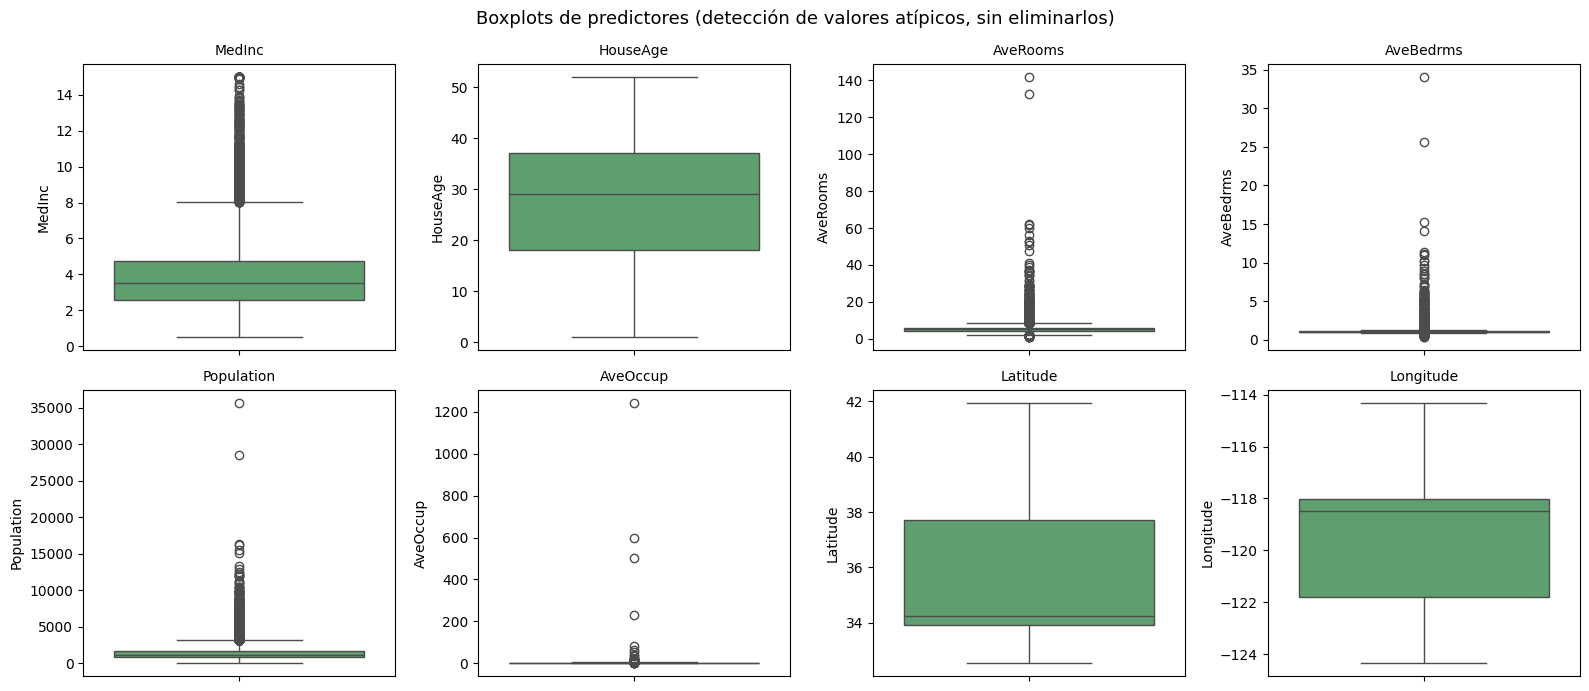

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

predictores = [c for c in df.columns if c != 'MedHouseVal']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(predictores):
    sns.boxplot(y=df[col], ax=axes[i], color='#55A868')
    axes[i].set_title(col, fontsize=10)
plt.suptitle('Boxplots de predictores (detección de valores atípicos, sin eliminarlos)', fontsize=13)
plt.tight_layout()
# Guarda la figura en PNG antes de mostrarla
plt.savefig(FIG_DIR / '01_boxplots_predictores.png', dpi=180, bbox_inches='tight')
plt.show()

In [8]:
from scipy import stats as sp_stats

outlier_summary = []
for col in predictores:
    z = sp_stats.zscore(df[col])
    n_out = (abs(z) > 3).sum()
    pct = 100 * n_out / len(df)
    outlier_summary.append({'Variable': col, 'N_outliers_|z|>3': n_out, '%_del_dataset': round(pct, 2)})

pd.DataFrame(outlier_summary)

,Variable,N_outliers_|z|>3,%_del_dataset
0,MedInc,345,1.67
1,HouseAge,0,0.00
2,AveRooms,133,0.64
3,AveBedrms,145,0.70
4,Population,342,1.66
5,AveOccup,8,0.04
6,Latitude,0,0.00
7,Longitude,0,0.00


**Decisión sobre valores atípicos.** Con el criterio |z|>3 mostrado arriba, se detectan outliers en `MedInc` (345, 1.67%), `Population` (342, 1.66%), `AveBedrms` (145, 0.70%), `AveRooms` (133, 0.64%) y, en menor medida, `AveOccup` (8, 0.04%); `HouseAge`, `Latitude` y `Longitude` no presentan outliers bajo este criterio. Se documentan pero **no se eliminan**: corresponden a distritos censales reales (zonas de baja o alta densidad extrema, o de ingreso muy alto), no a errores de captura, y su eliminación alteraría la representatividad del dataset sin evidencia de que sean datos inválidos. Los modelos basados en árboles (Árbol de Decisión, Random Forest) son naturalmente robustos a estos valores; la Regresión Lineal y el MLP sí pueden verse influenciados, lo que se considera al interpretar sus resultados.

## 4. Análisis exploratorio orientado al modelamiento

### 4.1 Distribución de la variable objetivo

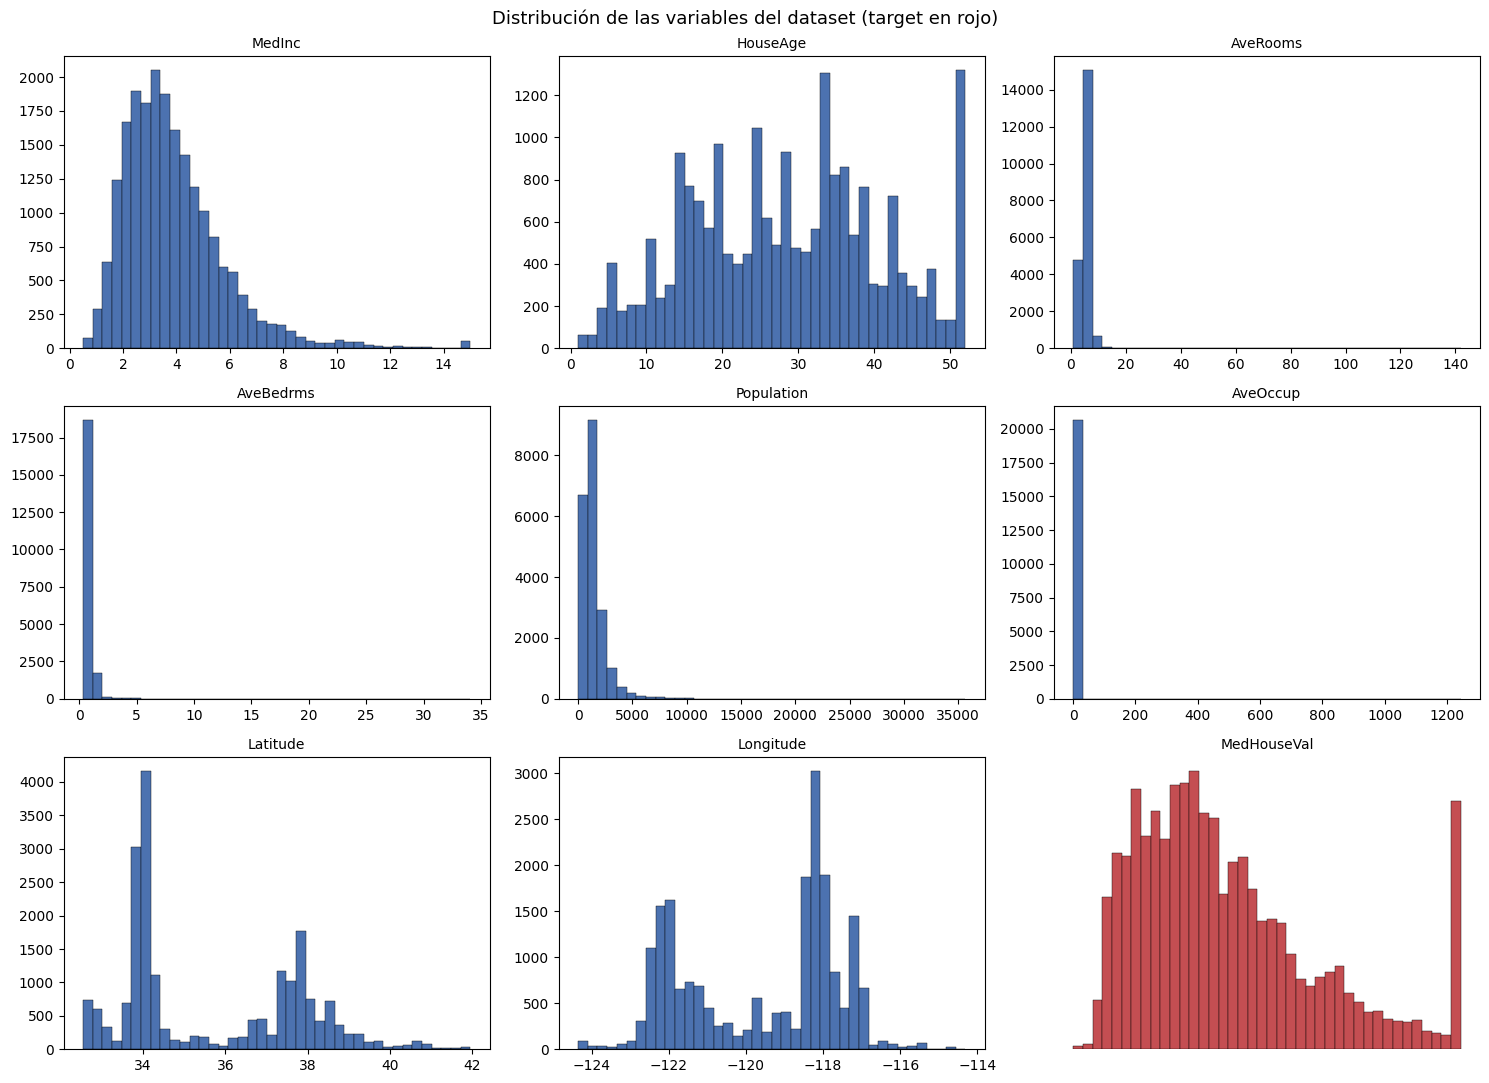

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()
for i, col in enumerate(df.columns):
    color = '#C44E52' if col == 'MedHouseVal' else '#4C72B0'
    axes[i].hist(df[col], bins=40, color=color, edgecolor='black', linewidth=0.3)
    axes[i].set_title(col, fontsize=10)
axes[-1].axis('off')
plt.suptitle('Distribución de las variables del dataset (target en rojo)', fontsize=13)
plt.tight_layout()
# Guarda la figura en PNG antes de mostrarla
plt.savefig(FIG_DIR / '02_distribuciones_variables.png', dpi=180, bbox_inches='tight')
plt.show()

**Lectura de las distribuciones.** `MedHouseVal` está truncada en 5.00001 (tope censal del valor de vivienda), lo que genera una acumulación de observaciones en ese valor máximo — un límite del propio proceso de recolección de datos, no un error. `AveRooms`, `AveBedrms`, `Population` y `AveOccup` muestran colas largas hacia la derecha, mientras que `Latitude`/`Longitude` muestran la conocida bimodalidad geográfica de California (Los Ángeles y la Bahía de San Francisco).

### 4.2 Correlaciones

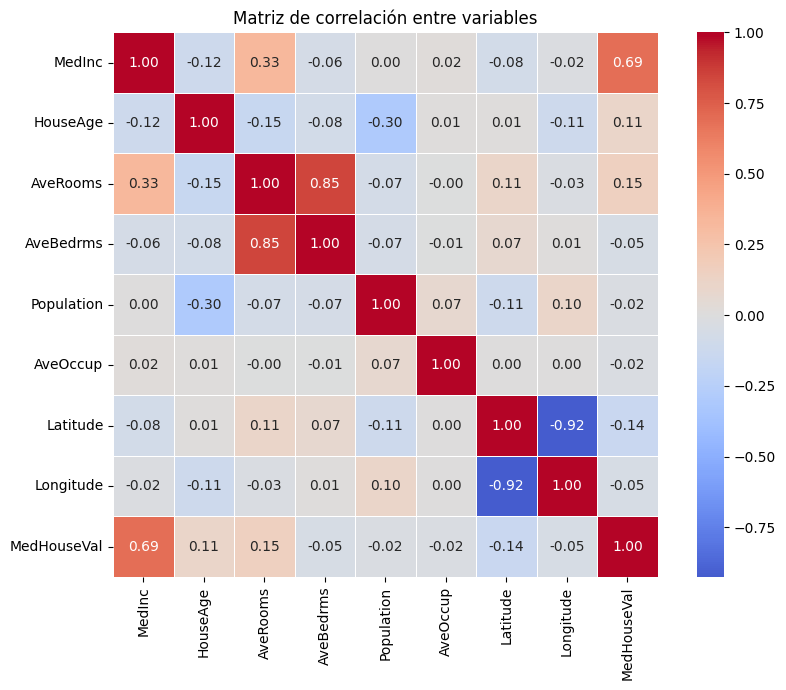

In [10]:
plt.figure(figsize=(9, 7))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Matriz de correlación entre variables')
plt.tight_layout()
# Guarda la figura en PNG antes de mostrarla
plt.savefig(FIG_DIR / '03_matriz_correlacion.png', dpi=180, bbox_inches='tight')
plt.show()

In [11]:
corr_target = df.corr()['MedHouseVal'].drop('MedHouseVal').sort_values(key=abs, ascending=False)
print("Correlación de cada predictor con MedHouseVal (ordenado por magnitud):")
print(corr_target)

Correlación de cada predictor con MedHouseVal (ordenado por magnitud):
MedInc        0.688075
AveRooms      0.151948
Latitude     -0.144160
HouseAge      0.105623
AveBedrms    -0.046701
Longitude    -0.045967
Population   -0.024650
AveOccup     -0.023737
Name: MedHouseVal, dtype: float64


**Interpretación de las correlaciones (con los valores reales obtenidos arriba).** `MedInc` es, por amplio margen, el predictor más correlacionado con `MedHouseVal`. `Latitude` y `Longitude` muestran correlación lineal moderada-baja porque su relación con el precio es geográfica (zonas costeras específicas), no una tendencia monotónica simple — la correlación de Pearson subestima su relevancia real. Entre predictores, `AveRooms` y `AveBedrms` muestran correlación relativamente alta entre sí, lo cual es esperable (ambas dependen del tamaño de la vivienda), pero no se elimina ninguna variable: los modelos usados no exigen ausencia de colinealidad para funcionar; solo afectaría la interpretación aislada de coeficientes en la Regresión Lineal.

### 4.3 Relación entre predictor principal y objetivo

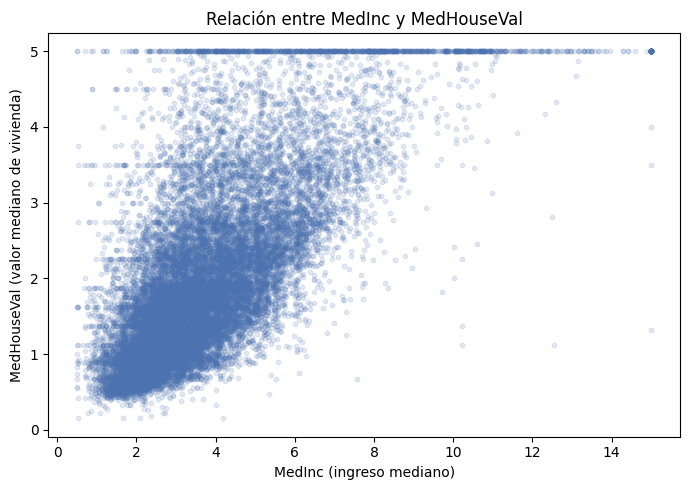

In [12]:
plt.figure(figsize=(7, 5))
plt.scatter(df['MedInc'], df['MedHouseVal'], alpha=0.15, s=10, color='#4C72B0')
plt.xlabel('MedInc (ingreso mediano)')
plt.ylabel('MedHouseVal (valor mediano de vivienda)')
plt.title('Relación entre MedInc y MedHouseVal')
plt.tight_layout()
# Guarda la figura en PNG antes de mostrarla
plt.savefig(FIG_DIR / '04_medinc_vs_medhouseval.png', dpi=180, bbox_inches='tight')
plt.show()

**Lectura del gráfico.** Se observa una relación positiva y razonablemente lineal entre `MedInc` y `MedHouseVal`, consistente con la correlación calculada arriba. También es visible el techo en 5.00001 y una dispersión creciente a medida que aumenta el ingreso, lo que sugiere que un modelo puramente lineal tendrá más dificultad para capturar la variabilidad en distritos de altos ingresos.

### 4.4 Decisiones derivadas del EDA

| Decisión | Evidencia del EDA |
|---|---|
| `MedInc` se usa como predictor único en la Regresión Lineal Simple | Es el predictor con mayor correlación con `MedHouseVal` (Sección 4.2) y muestra la relación más lineal en el gráfico de dispersión (Sección 4.3) |
| Se conservan los 8 predictores en el modelo multivariable complementario | Permite evaluar cuánto mejora el desempeño al incorporar información adicional respecto del modelo simple |
| No se eliminan outliers | Corresponden a distritos reales, no a errores (Sección 3.5) |
| Escalamiento aplicado solo a Regresión Lineal (simple y multivariable) y MLP | Árbol de Decisión y Random Forest dividen por umbrales y no requieren escalamiento (se detalla en Sección 5.3) |

## 5. Preparación para modelamiento

### 5.1 Definición X / y

In [13]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")

Dimensiones de X: (20640, 8)
Dimensiones de y: (20640,)


### 5.2 Train/test

Se particiona el dataset en 80% entrenamiento / 20% prueba con `random_state=RANDOM_STATE`. El conjunto de prueba se reserva exclusivamente para la evaluación final.

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}  |  y_test: {y_test.shape}")

X_train: (16512, 8)  |  X_test: (4128, 8)
y_train: (16512,)  |  y_test: (4128,)


### 5.3 Escalamiento

La Regresión Lineal ordinaria puede entrenarse sin escalamiento: sus coeficientes y su desempeño predictivo no dependen de la escala de las variables. En este análisis se utilizan variables estandarizadas para la Regresión Lineal Multivariable (Sección 7) por consistencia en el preprocesamiento y para que la magnitud de los coeficientes sea comparable entre predictores (Sección 7.1); no es un requisito metodológico del modelo. El escalamiento sí resulta especialmente relevante para el MLP (Sección 9), donde favorece un entrenamiento numéricamente estable y una mejor convergencia del descenso de gradiente (Géron, 2019). El Árbol de Decisión y Random Forest, en cambio, dividen el espacio de predictores evaluando umbrales por variable de forma independiente (p. ej. `MedInc <= 3.5`); el orden relativo de los valores no cambia al escalar, por lo tanto **no requieren escalamiento** y se entrenan con las variables originales.

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Escalador ajustado solo con X_train.")
pd.DataFrame(X_train_scaled, columns=X.columns).describe().T[['mean', 'std']]

Escalador ajustado solo con X_train.


,mean,std
MedInc,-6.519333e-17,1.00003
HouseAge,-9.251859e-18,1.00003
AveRooms,-1.981081e-16,1.00003
AveBedrms,-1.707291e-16,1.00003
Population,-2.151595e-19,1.00003
AveOccup,4.936566e-17,1.00003
Latitude,6.400995e-17,1.00003
Longitude,1.753335e-15,1.00003


### 5.4 Control de data leakage

El `StandardScaler` se ajusta (`fit`) únicamente con `X_train` y luego se aplica (`transform`) tanto a `X_train` como a `X_test`. Nunca se ajusta con el dataset completo antes de separar entrenamiento y prueba: hacerlo filtraría información del conjunto de prueba hacia el preprocesamiento (data leakage) y produciría una estimación optimista del desempeño real del modelo. La misma partición (`X_train`/`X_test`, `y_train`/`y_test`) se reutiliza en los cinco modelos de este notebook para que la comparación final sea válida.

## 6. Regresión Lineal Simple — **modelo obligatorio**

### 6.1 Definición

La Regresión Lineal Simple utiliza un único predictor `X` para estimar la variable continua `Y` mediante Ŷ = β0 + β1·X, donde β0 es el intercepto y β1 representa el cambio esperado en `Y` asociado a una unidad adicional de `X`. Se emplea aquí como **modelo base**, altamente interpretable, antes de incorporar predictores adicionales o modelos no lineales (Ruete, 2026a; Draper & Smith, 1998). La interpretación de β1 se hace como **asociación predictiva**, no como relación causal.

### 6.2 Variable seleccionada

Se selecciona `MedInc` como único predictor, con base en la evidencia del EDA (Sección 4.2 y 4.4): es el predictor con mayor correlación de Pearson con `MedHouseVal` y el que exhibe la relación más lineal en el gráfico de dispersión. No se escala esta variable: al tratarse de un único predictor, el escalamiento no altera el ajuste del modelo ni su R², y mantener `MedInc` en su unidad original (decenas de miles de USD) facilita interpretar directamente el coeficiente estimado.

### 6.3 Entrenamiento

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

X_train_simple = X_train[['MedInc']]
X_test_simple = X_test[['MedInc']]

simple_model = LinearRegression()
simple_model.fit(X_train_simple, y_train)

print("Regresión Lineal Simple entrenada con MedInc como único predictor.")

Regresión Lineal Simple entrenada con MedInc como único predictor.


### 6.4 Intercepto y pendiente

In [17]:
beta0 = simple_model.intercept_
beta1 = simple_model.coef_[0]

print(f"Intercepto (b0): {beta0:.4f}")
print(f"Pendiente  (b1): {beta1:.4f}")
print(f"\nEcuación estimada: MedHouseVal = {beta0:.4f} + {beta1:.4f} * MedInc")

Intercepto (b0): 0.4446
Pendiente  (b1): 0.4193

Ecuación estimada: MedHouseVal = 0.4446 + 0.4193 * MedInc


### 6.5 Predicciones

In [18]:
y_pred_simple_train = simple_model.predict(X_train_simple)
y_pred_simple = simple_model.predict(X_test_simple)

pd.DataFrame({
    'MedInc (real)': X_test_simple['MedInc'].values[:5],
    'MedHouseVal (real)': y_test.values[:5],
    'MedHouseVal (predicho)': y_pred_simple[:5]
})

,MedInc (real),MedHouseVal (real),MedHouseVal (predicho)
0,1.6812,0.47700,1.149589
1,2.5313,0.45800,1.506069
2,3.4801,5.00001,1.903937
3,5.7376,2.18600,2.850594
4,3.7250,2.78000,2.006633


### 6.6 MSE, RMSE y R²

In [19]:
mse_simple = mean_squared_error(y_test, y_pred_simple)
rmse_simple = root_mean_squared_error(y_test, y_pred_simple)
r2_simple = r2_score(y_test, y_pred_simple)
r2_simple_train = r2_score(y_train, y_pred_simple_train)

print("--- Regresión Lineal Simple (MedInc -> MedHouseVal) ---")
print(f"MSE (prueba):  {mse_simple:.4f}")
print(f"RMSE (prueba): {rmse_simple:.4f}")
print(f"R2 (prueba):   {r2_simple:.4f}")
print(f"R2 (entrenamiento): {r2_simple_train:.4f}")

--- Regresión Lineal Simple (MedInc -> MedHouseVal) ---
MSE (prueba):  0.7091
RMSE (prueba): 0.8421
R2 (prueba):   0.4589
R2 (entrenamiento): 0.4770


### 6.7 Visualización

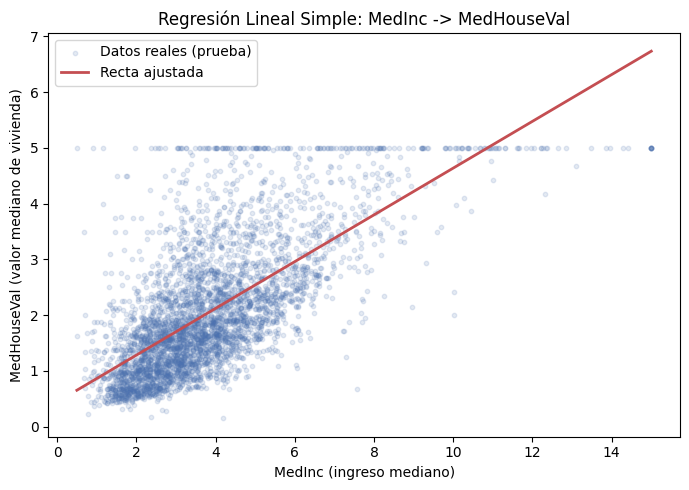

In [20]:
plt.figure(figsize=(7, 5))
plt.scatter(X_test_simple['MedInc'], y_test, alpha=0.15, s=10, color='#4C72B0', label='Datos reales (prueba)')
orden = X_test_simple['MedInc'].sort_values().index
plt.plot(X_test_simple.loc[orden, 'MedInc'], simple_model.predict(X_test_simple.loc[orden]),
         color='#C44E52', linewidth=2, label='Recta ajustada')
plt.xlabel('MedInc (ingreso mediano)')
plt.ylabel('MedHouseVal (valor mediano de vivienda)')
plt.title('Regresión Lineal Simple: MedInc -> MedHouseVal')
plt.legend()
plt.tight_layout()
# Guarda la figura en PNG antes de mostrarla
plt.savefig(FIG_DIR / '05_regresion_lineal_simple.png', dpi=180, bbox_inches='tight')
plt.show()

### 6.8 Interpretación

**Interpretación (con los resultados reales obtenidos arriba).** La pendiente positiva confirma que, en promedio, un mayor ingreso mediano del distrito se asocia a un mayor valor mediano de vivienda, consistente con la correlación calculada en la Sección 4.2. El R² de prueba indica la proporción de la variabilidad de `MedHouseVal` que este único predictor logra explicar; al usar solo una variable, se espera que quede un margen de error considerable, dado que el gráfico de dispersión (Sección 4.3) ya mostraba una dispersión creciente en distritos de mayor ingreso que un modelo lineal simple no puede capturar. El R² de entrenamiento y de prueba son similares entre sí, lo que indica que el modelo no está sobreajustado — es coherente con su baja flexibilidad (una sola recta). Este resultado sirve como línea base: en la Sección 7 se evalúa cuánto mejora el desempeño al incorporar los 7 predictores restantes.

## 7. Regresión Lineal Multivariable — **análisis complementario**

Como extensión del modelo base de la Sección 6, se incorporan los 8 predictores simultáneamente. Cada coeficiente representa el cambio esperado en `MedHouseVal` ante un cambio de una desviación estándar en el predictor correspondiente (las variables están escaladas), manteniendo las demás constantes. Este modelo **no reemplaza** a la Regresión Lineal Simple exigida por la pauta; se mantiene como análisis complementario para cuantificar la ganancia de desempeño al usar toda la información disponible.

In [21]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

y_pred_linear_train = linear_model.predict(X_train_scaled)
y_pred_linear = linear_model.predict(X_test_scaled)

mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = root_mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)
r2_linear_train = r2_score(y_train, y_pred_linear_train)

print("--- Regresión Lineal Multivariable (8 predictores) ---")
print(f"MSE (prueba):  {mse_linear:.4f}")
print(f"RMSE (prueba): {rmse_linear:.4f}")
print(f"R2 (prueba):   {r2_linear:.4f}")
print(f"R2 (entrenamiento): {r2_linear_train:.4f}")

--- Regresión Lineal Multivariable (8 predictores) ---


MSE (prueba):  0.5559
RMSE (prueba): 0.7456
R2 (prueba):   0.5758
R2 (entrenamiento): 0.6126


In [22]:
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': linear_model.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)
coef_df

,Variable,Coeficiente
6,Latitude,-0.896929
7,Longitude,-0.869842
0,MedInc,0.854383
3,AveBedrms,0.339259
2,AveRooms,-0.294410
1,HouseAge,0.122546
5,AveOccup,-0.040829
4,Population,-0.002308


**Interpretación (con los resultados reales obtenidos arriba).** El R² de prueba (0.576) supera claramente al de la Regresión Lineal Simple (0.459, Sección 6.6), lo que cuantifica el aporte de incorporar los 7 predictores adicionales. Según la tabla de coeficientes, `Latitude` (-0.897) y `Longitude` (-0.870) presentan las magnitudes más altas, muy cerca de `MedInc` (0.854): la ubicación geográfica pesa tanto como el ingreso una vez que todas las variables están escaladas y se estima conjuntamente, lo que confirma que la correlación lineal simple (Sección 4.2) subestimaba la relevancia real de la latitud y la longitud. El R² de entrenamiento (0.613) y de prueba (0.576) permanecen razonablemente cercanos entre sí, lo que indica que el modelo no está fuertemente sobreajustado.

## 8. Árbol de Decisión para Regresión (modelo obligatorio)

### 8.1 Definición

Un árbol de regresión no asume una relación lineal global: divide recursivamente el espacio de predictores en regiones y asigna a cada hoja el promedio de `MedHouseVal` de las observaciones que caen en ella. Puede capturar no linealidades, interacciones y umbrales que la Regresión Lineal no representa directamente. Su principal riesgo es la **alta varianza**: un árbol demasiado profundo memoriza el entrenamiento y generaliza mal — es decir, existe un compromiso entre profundidad, complejidad y la relación sesgo/varianza: un árbol muy poco profundo tiende a subajustar (alto sesgo, no captura patrones reales), mientras que uno muy profundo tiende a sobreajustar (alta varianza, memoriza ruido específico del entrenamiento) (Ruete, 2026b; Hastie et al., 2009).

### 8.2 Hiperparámetros

El árbol se entrena sobre `X_train`/`X_test` **sin escalar** (Sección 5.3): al dividir por umbrales, la escala de las variables no afecta sus resultados. El hiperparámetro central que controla la complejidad del árbol es `max_depth`, junto con `min_samples_split` y `min_samples_leaf` (se dejan en su valor por defecto de scikit-learn, ya que el análisis de la Sección 8.3 se concentra en `max_depth`). `random_state=RANDOM_STATE` se fija por reproducibilidad.

### 8.3 Control de profundidad (selección por validación interna)

`max_depth` no puede seleccionarse observando el desempeño sobre `X_test`/`y_test`: ese conjunto está reservado exclusivamente para la evaluación final, y usarlo para elegir un hiperparámetro equivale a "filtrar" información de prueba hacia el proceso de entrenamiento (una forma de fuga de información), lo que produciría una estimación optimista y no confiable del desempeño real del modelo.

En su lugar, se separa una partición de **validación interna** a partir de `X_train`/`y_train` (80% entrenamiento interno / 20% validación, con `random_state=RANDOM_STATE`). Se entrena el árbol con distintas profundidades usando solo el entrenamiento interno, y se evalúa cada una sobre la validación — `X_test`/`y_test` no participa en ningún momento de esta comparación.

X_train_sub: (13209, 8)  |  X_val: (3303, 8)


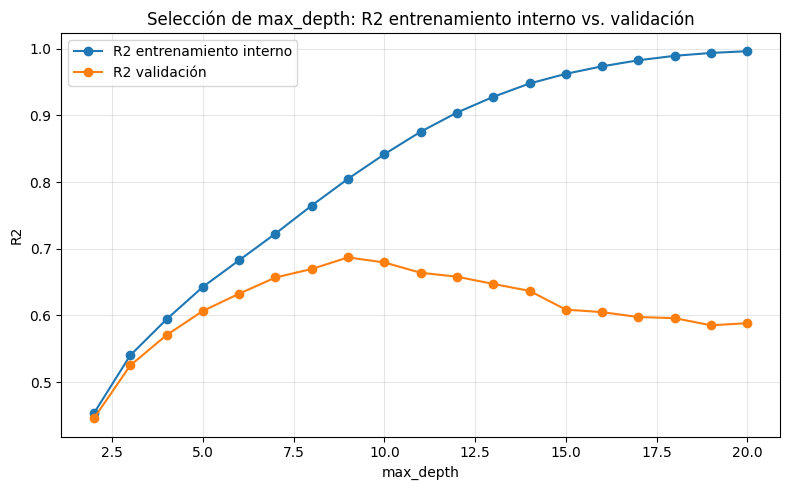

Profundidad con mayor R2 de validación: 9 (R2 validación = 0.6870)


In [23]:
from sklearn.tree import DecisionTreeRegressor

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.20, random_state=RANDOM_STATE
)

print(f"X_train_sub: {X_train_sub.shape}  |  X_val: {X_val.shape}")

profundidades = range(2, 21)
r2_train_list, r2_val_list = [], []

for d in profundidades:
    tree_tmp = DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE)
    tree_tmp.fit(X_train_sub, y_train_sub)
    r2_train_list.append(r2_score(y_train_sub, tree_tmp.predict(X_train_sub)))
    r2_val_list.append(r2_score(y_val, tree_tmp.predict(X_val)))

plt.figure(figsize=(8, 5))
plt.plot(list(profundidades), r2_train_list, marker='o', label='R2 entrenamiento interno')
plt.plot(list(profundidades), r2_val_list, marker='o', label='R2 validación')
plt.xlabel('max_depth')
plt.ylabel('R2')
plt.title('Selección de max_depth: R2 entrenamiento interno vs. validación')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
# Guarda la figura en PNG antes de mostrarla
plt.savefig(FIG_DIR / '06_seleccion_profundidad_arbol.png', dpi=180, bbox_inches='tight')
plt.show()

mejor_depth = list(profundidades)[int(np.argmax(r2_val_list))]
print(f"Profundidad con mayor R2 de validación: {mejor_depth} (R2 validación = {max(r2_val_list):.4f})")

**Justificación del `max_depth` elegido (según el resultado real de la celda anterior).** El R² de entrenamiento interno crece monótonamente con la profundidad (el árbol memoriza cada vez mejor esos datos), mientras que el R² de validación mejora hasta cierto punto y luego se estanca o empeora levemente — ese punto de inflexión es evidencia de sobreajuste más allá de esa profundidad. Se usa la profundidad con mejor R² de **validación** (impresa arriba) como valor final; ni `X_test` ni `y_test` participaron en esta decisión, por lo que la evaluación final sobre el conjunto de prueba (Sección 8.6) sigue siendo una estimación honesta del desempeño fuera de muestra.

### 8.4 Entrenamiento

Una vez seleccionado `max_depth` usando solo la partición de validación, el árbol definitivo se **reentrena con todo `X_train`/`y_train`** (sin descartar el 20% que se había apartado como validación), de modo que aproveche toda la información disponible antes de la evaluación final.

In [24]:
BEST_DEPTH = mejor_depth

decision_tree_model = DecisionTreeRegressor(max_depth=BEST_DEPTH, random_state=RANDOM_STATE)
decision_tree_model.fit(X_train, y_train)

print(f"Árbol de Decisión entrenado con max_depth={BEST_DEPTH}, random_state={RANDOM_STATE}.")

Árbol de Decisión entrenado con max_depth=9, random_state=42.


### 8.5 Predicciones

In [25]:
y_pred_tree_train = decision_tree_model.predict(X_train)
y_pred_tree = decision_tree_model.predict(X_test)

pd.DataFrame({
    'MedHouseVal (real)': y_test.values[:5],
    'MedHouseVal (predicho)': y_pred_tree[:5]
})

,MedHouseVal (real),MedHouseVal (predicho)
0,0.47700,0.558394
1,0.45800,0.774487
2,5.00001,4.871595
3,2.18600,2.229754
4,2.78000,2.126351


### 8.6 MSE, RMSE y R²

In [26]:
mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = root_mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)
r2_tree_train = r2_score(y_train, y_pred_tree_train)

print(f"--- Árbol de Decisión (max_depth={BEST_DEPTH}) ---")
print(f"MSE (prueba):  {mse_tree:.4f}")
print(f"RMSE (prueba): {rmse_tree:.4f}")
print(f"R2 (prueba):   {r2_tree:.4f}")
print(f"R2 (entrenamiento): {r2_tree_train:.4f}")

--- Árbol de Decisión (max_depth=9) ---
MSE (prueba):  0.4151
RMSE (prueba): 0.6443
R2 (prueba):   0.6833
R2 (entrenamiento): 0.7999


In [27]:
importancia_tree = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': decision_tree_model.feature_importances_
}).sort_values('Importancia', ascending=False)
importancia_tree

,Variable,Importancia
0,MedInc,0.631555
5,AveOccup,0.131729
6,Latitude,0.075473
7,Longitude,0.058643
1,HouseAge,0.043700
2,AveRooms,0.036752
4,Population,0.011276
3,AveBedrms,0.010872


### 8.7 Interpretación

**Interpretación (con resultados reales).** La brecha entre el R² de entrenamiento y de prueba del árbol final da cuenta del compromiso profundidad-complejidad-generalización descrito en la Sección 8.1: una brecha amplia indicaría que, pese a seleccionar `max_depth` por validación, persiste sobreajuste; una brecha moderada indica que la profundidad elegida generaliza razonablemente. En cualquier caso, el R² de prueba del árbol se compara con el de la Regresión Lineal Simple (Sección 6.6) y la Multivariable (Sección 7) para evaluar si capturar no linealidades e interacciones aporta una ganancia real de desempeño en este dataset. La tabla de importancia de variables muestra qué predictores concentran la mayor parte de las divisiones del árbol; `MedInc` presenta la mayor asociación predictiva individual con `MedHouseVal` dentro de este análisis, sin que ello implique una relación causal, y puede contrastarse con los coeficientes de la Regresión Lineal Multivariable (Sección 7).

## 9. Red Neuronal MLP — **modelo obligatorio**

### 9.1 Arquitectura

Un `MLPRegressor` (Perceptrón Multicapa) es capaz de capturar relaciones no lineales complejas mediante una capa de entrada (los 8 predictores), una o más capas ocultas de neuronas interconectadas con pesos y sesgos ajustables, y una capa de salida continua (una neurona, sin función de activación, para regresión). El entrenamiento se basa en forward propagation, una función de pérdida, backpropagation y optimización iterativa de los pesos (Ruete, 2026d; Géron, 2019).

### 9.2 Hiperparámetros

Se documentan explícitamente los hiperparámetros utilizados:

| Hiperparámetro | Valor | Función |
|---|---|---|
| `hidden_layer_sizes` | (100,) | Una capa oculta de 100 neuronas |
| `activation` | 'relu' | Función de activación no lineal en la capa oculta |
| `solver` | 'adam' | Algoritmo de optimización del descenso de gradiente |
| `max_iter` | 500 | Máximo de iteraciones de entrenamiento |
| `early_stopping` | True | Detiene el entrenamiento si el error de validación deja de mejorar, como control adicional contra el sobreajuste |
| `random_state` | 42 | Reproducibilidad de la inicialización de pesos y del split interno de validación |

### 9.3 Escalamiento

A diferencia de los modelos basados en árboles, el MLP se beneficia especialmente del escalamiento de las variables. Al optimizarse mediante métodos iterativos basados en gradiente, variables en escalas muy diferentes (p. ej. `Population` en miles vs. `AveRooms` en unidades) pueden dificultar o ralentizar la convergencia (Ruete, 2026d; Géron, 2019). Por ello, en este análisis se utilizan `X_train_scaled`/`X_test_scaled`, obtenidos mediante un escalador ajustado exclusivamente con los datos de entrenamiento (Sección 5.3 y 5.4).

### 9.4 Entrenamiento

In [28]:
from sklearn.neural_network import MLPRegressor

mlp_model = MLPRegressor(
    hidden_layer_sizes=(100,), activation='relu', solver='adam',
    max_iter=500, random_state=RANDOM_STATE, early_stopping=True
)
mlp_model.fit(X_train_scaled, y_train)

print("Red Neuronal (MLP) entrenada sobre las variables escaladas.")

Red Neuronal (MLP) entrenada sobre las variables escaladas.


### 9.5 Convergencia

In [29]:
print(f"Iteraciones ejecutadas: {mlp_model.n_iter_} (máximo permitido: {mlp_model.max_iter})")
print(f"Función de pérdida final: {mlp_model.loss_:.5f}")

Iteraciones ejecutadas: 153 (máximo permitido: 500)
Función de pérdida final: 0.13855


**Lectura de la convergencia.** Si el número de iteraciones ejecutadas es menor que `max_iter`, el entrenamiento se detuvo por `early_stopping` (el error de validación interna dejó de mejorar), lo que es una señal de que el modelo no siguió ajustándose innecesariamente sobre el conjunto de entrenamiento.

### 9.6 Predicciones

In [30]:
y_pred_mlp_train = mlp_model.predict(X_train_scaled)
y_pred_mlp = mlp_model.predict(X_test_scaled)

pd.DataFrame({
    'MedHouseVal (real)': y_test.values[:5],
    'MedHouseVal (predicho)': y_pred_mlp[:5]
})

,MedHouseVal (real),MedHouseVal (predicho)
0,0.47700,0.374690
1,0.45800,1.174805
2,5.00001,4.754145
3,2.18600,2.547741
4,2.78000,2.916866


### 9.7 MSE, RMSE y R²

In [31]:
mse_mlp = mean_squared_error(y_test, y_pred_mlp)
rmse_mlp = root_mean_squared_error(y_test, y_pred_mlp)
r2_mlp = r2_score(y_test, y_pred_mlp)
r2_mlp_train = r2_score(y_train, y_pred_mlp_train)

print("--- Red Neuronal (MLP) ---")
print(f"MSE (prueba):  {mse_mlp:.4f}")
print(f"RMSE (prueba): {rmse_mlp:.4f}")
print(f"R2 (prueba):   {r2_mlp:.4f}")
print(f"R2 (entrenamiento): {r2_mlp_train:.4f}")

--- Red Neuronal (MLP) ---
MSE (prueba):  0.3017
RMSE (prueba): 0.5493
R2 (prueba):   0.7697
R2 (entrenamiento): 0.7898


### 9.8 Interpretación

**Interpretación (con resultados reales).** El MLP no ofrece coeficientes ni importancia de variables interpretables directamente; su evaluación se basa exclusivamente en las métricas de desempeño. Con R² de prueba = 0.770 y RMSE = 0.549, el MLP es el mejor de los tres modelos obligatorios, superando al Árbol de Decisión (0.683) y a la Regresión Lineal Simple (0.459); esto confirma que su capacidad de modelar no linealidades **sí se tradujo en un mejor resultado** en este dataset, aunque la comparación con el Random Forest complementario (Sección 10) determina si esa ventaja se mantiene frente a otro modelo no lineal. La brecha entre el R² de entrenamiento (0.790) y de prueba (0.770) es pequeña (0.020), la más pequeña de los cinco modelos, lo que indica que `early_stopping` fue efectivo para controlar el sobreajuste.

## 10. Random Forest — **análisis complementario**

Random Forest no es obligatorio en esta evaluación, pero ya estaba correctamente implementado en la versión previa del notebook y aporta evidencia adicional: combina múltiples árboles de decisión entrenados sobre submuestras bootstrap y subconjuntos aleatorios de variables (bagging), y promedia sus predicciones (Breiman, 2001; Ruete, 2026c). Esto suele reducir la varianza respecto de un único árbol, a costa de perder parte de la interpretabilidad directa. Tampoco requiere escalamiento, por la misma razón que el Árbol de Decisión (Sección 5.3).

Hiperparámetros utilizados: `n_estimators=300`, `max_depth=None`, `random_state=RANDOM_STATE`.

In [32]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300, max_depth=None, random_state=RANDOM_STATE, n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_rf_train = rf_model.predict(X_train)
y_pred_rf = rf_model.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = root_mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
r2_rf_train = r2_score(y_train, y_pred_rf_train)

print("--- Random Forest Regressor (complementario) ---")
print(f"MSE (prueba):  {mse_rf:.4f}")
print(f"RMSE (prueba): {rmse_rf:.4f}")
print(f"R2 (prueba):   {r2_rf:.4f}")
print(f"R2 (entrenamiento): {r2_rf_train:.4f}")

--- Random Forest Regressor (complementario) ---
MSE (prueba):  0.2537
RMSE (prueba): 0.5036
R2 (prueba):   0.8064
R2 (entrenamiento): 0.9744


In [33]:
importancia_rf = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': rf_model.feature_importances_
}).sort_values('Importancia', ascending=False)
importancia_rf

,Variable,Importancia
0,MedInc,0.525739
5,AveOccup,0.138087
7,Longitude,0.088589
6,Latitude,0.088516
1,HouseAge,0.054228
2,AveRooms,0.044642
4,Population,0.030484
3,AveBedrms,0.029715


**Interpretación (con resultados reales).** El R² de prueba de Random Forest (0.807) supera al del Árbol de Decisión individual (0.683, Sección 8.6), lo que respalda el argumento teórico de que el promedio de múltiples árboles reduce la varianza y mejora la generalización. El R² de entrenamiento es muy alto (0.974) frente al de prueba (0.807) — una brecha de 0.167, la mayor de los cinco modelos — esperable dado que cada árbol individual puede ajustar fuertemente sus muestras bootstrap; pese a esa brecha, su R² de prueba sigue siendo el más alto de los cinco modelos evaluados. La importancia de variables se reporta con fines exploratorios: **importancia predictiva no implica causalidad**.

## 11. Evaluación consolidada

Se reúnen en una sola tabla las métricas de los cinco modelos entrenados: MSE, RMSE y R² sobre el conjunto de prueba, además del R² de entrenamiento para evaluar sobreajuste (Ruete, 2026e). Los tres primeros corresponden a los modelos obligatorios de esta fase; los dos últimos son análisis complementario. Ningún valor de esta tabla se escribe manualmente: todos provienen de las variables calculadas en las secciones anteriores.

In [34]:
results = pd.DataFrame({
    'Modelo': ['Regresión Lineal Simple', 'Árbol de Decisión', 'Red Neuronal (MLP)',
               'Regresión Lineal Multivariable', 'Random Forest'],
    'Tipo': ['Obligatorio', 'Obligatorio', 'Obligatorio', 'Complementario', 'Complementario'],
    'MSE': [mse_simple, mse_tree, mse_mlp, mse_linear, mse_rf],
    'RMSE': [rmse_simple, rmse_tree, rmse_mlp, rmse_linear, rmse_rf],
    'R2_prueba': [r2_simple, r2_tree, r2_mlp, r2_linear, r2_rf],
    'R2_entrenamiento': [r2_simple_train, r2_tree_train, r2_mlp_train, r2_linear_train, r2_rf_train],
})
results['Brecha_R2_(train-test)'] = results['R2_entrenamiento'] - results['R2_prueba']
results_ordenado = results.sort_values(by='R2_prueba', ascending=False).reset_index(drop=True)
results_ordenado

,Modelo,Tipo,MSE,RMSE,R2_prueba,R2_entrenamiento,Brecha_R2_(train-test)
0,Random Forest,Complementario,0.253654,0.503641,0.806431,0.974387,0.167956
1,Red Neuronal (MLP),Obligatorio,0.301732,0.549301,0.769742,0.789825,0.020083
2,Árbol de Decisión,Obligatorio,0.415068,0.644258,0.683253,0.799926,0.116673
3,Regresión Lineal Multivariable,Complementario,0.555892,0.745581,0.575788,0.612551,0.036763
4,Regresión Lineal Simple,Obligatorio,0.709116,0.842090,0.458859,0.476993,0.018134


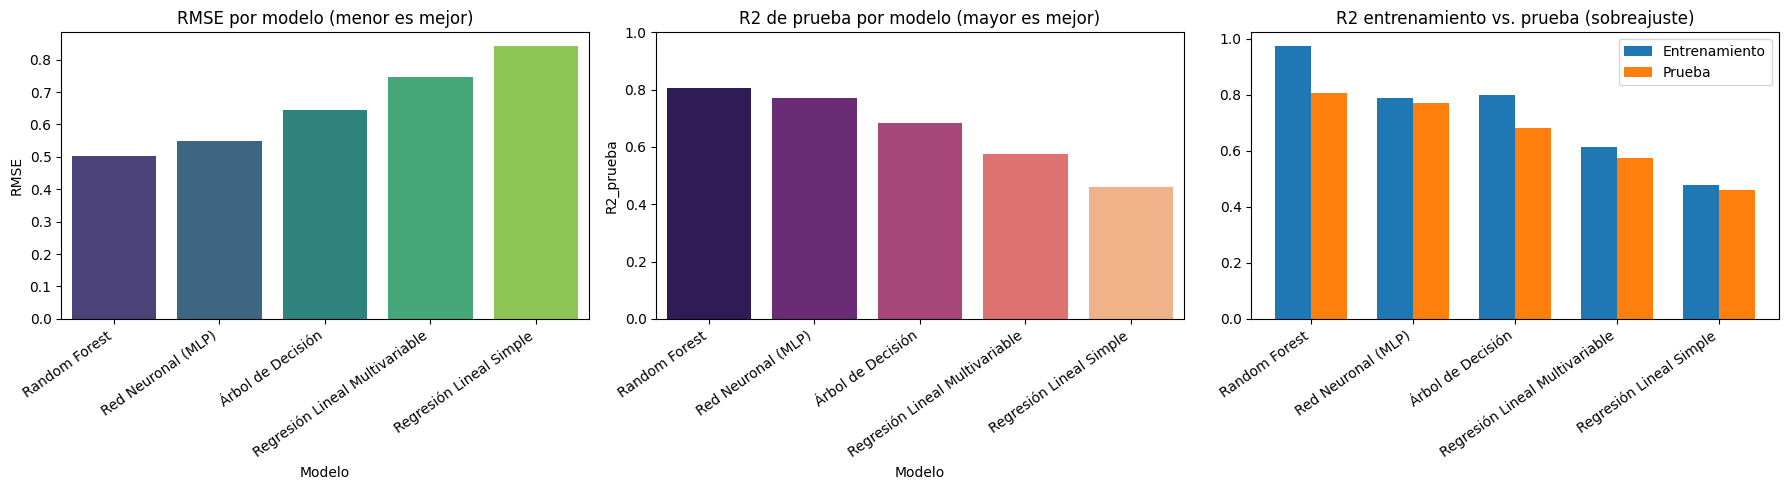

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(ax=axes[0], x='Modelo', y='RMSE', hue='Modelo', data=results_ordenado, palette='viridis', legend=False)
axes[0].set_title('RMSE por modelo (menor es mejor)')
axes[0].set_xticks(range(len(results_ordenado)))
axes[0].set_xticklabels(results_ordenado['Modelo'], rotation=35, ha='right')

sns.barplot(ax=axes[1], x='Modelo', y='R2_prueba', hue='Modelo', data=results_ordenado, palette='magma', legend=False)
axes[1].set_title('R2 de prueba por modelo (mayor es mejor)')
axes[1].set_ylim(0, 1)
axes[1].set_xticks(range(len(results_ordenado)))
axes[1].set_xticklabels(results_ordenado['Modelo'], rotation=35, ha='right')

x = np.arange(len(results_ordenado))
width = 0.35
axes[2].bar(x - width/2, results_ordenado['R2_entrenamiento'], width, label='Entrenamiento')
axes[2].bar(x + width/2, results_ordenado['R2_prueba'], width, label='Prueba')
axes[2].set_xticks(x)
axes[2].set_xticklabels(results_ordenado['Modelo'], rotation=35, ha='right')
axes[2].set_title('R2 entrenamiento vs. prueba (sobreajuste)')
axes[2].legend()

plt.tight_layout()
# Guarda la figura en PNG antes de mostrarla
plt.savefig(FIG_DIR / '07_comparacion_modelos_regresion.png', dpi=180, bbox_inches='tight')
plt.show()

**Interpretación de la evaluación consolidada.** El MSE queda expresado en unidades al cuadrado y no debe leerse directamente en las unidades originales de `MedHouseVal`; el RMSE, al volver a las unidades originales (cientos de miles de USD), es el más útil para una interpretación práctica del error. Un R² más alto indica mayor proporción de variabilidad explicada, pero por sí solo no demuestra que un modelo sea mejor (Ruete, 2026e; Hastie et al., 2009): debe leerse junto con el RMSE, la brecha train/test de la tercera gráfica (que evidencia cuánto sobreajusta cada modelo), los residuos (Sección 12) y la complejidad/interpretabilidad de cada modelo (Sección 13).

## 12. Diagnóstico

Se examinan los gráficos de valores reales vs. predichos y de residuos para los tres modelos obligatorios y los dos complementarios, con el fin de diagnosticar el comportamiento del error y no solo su magnitud agregada.

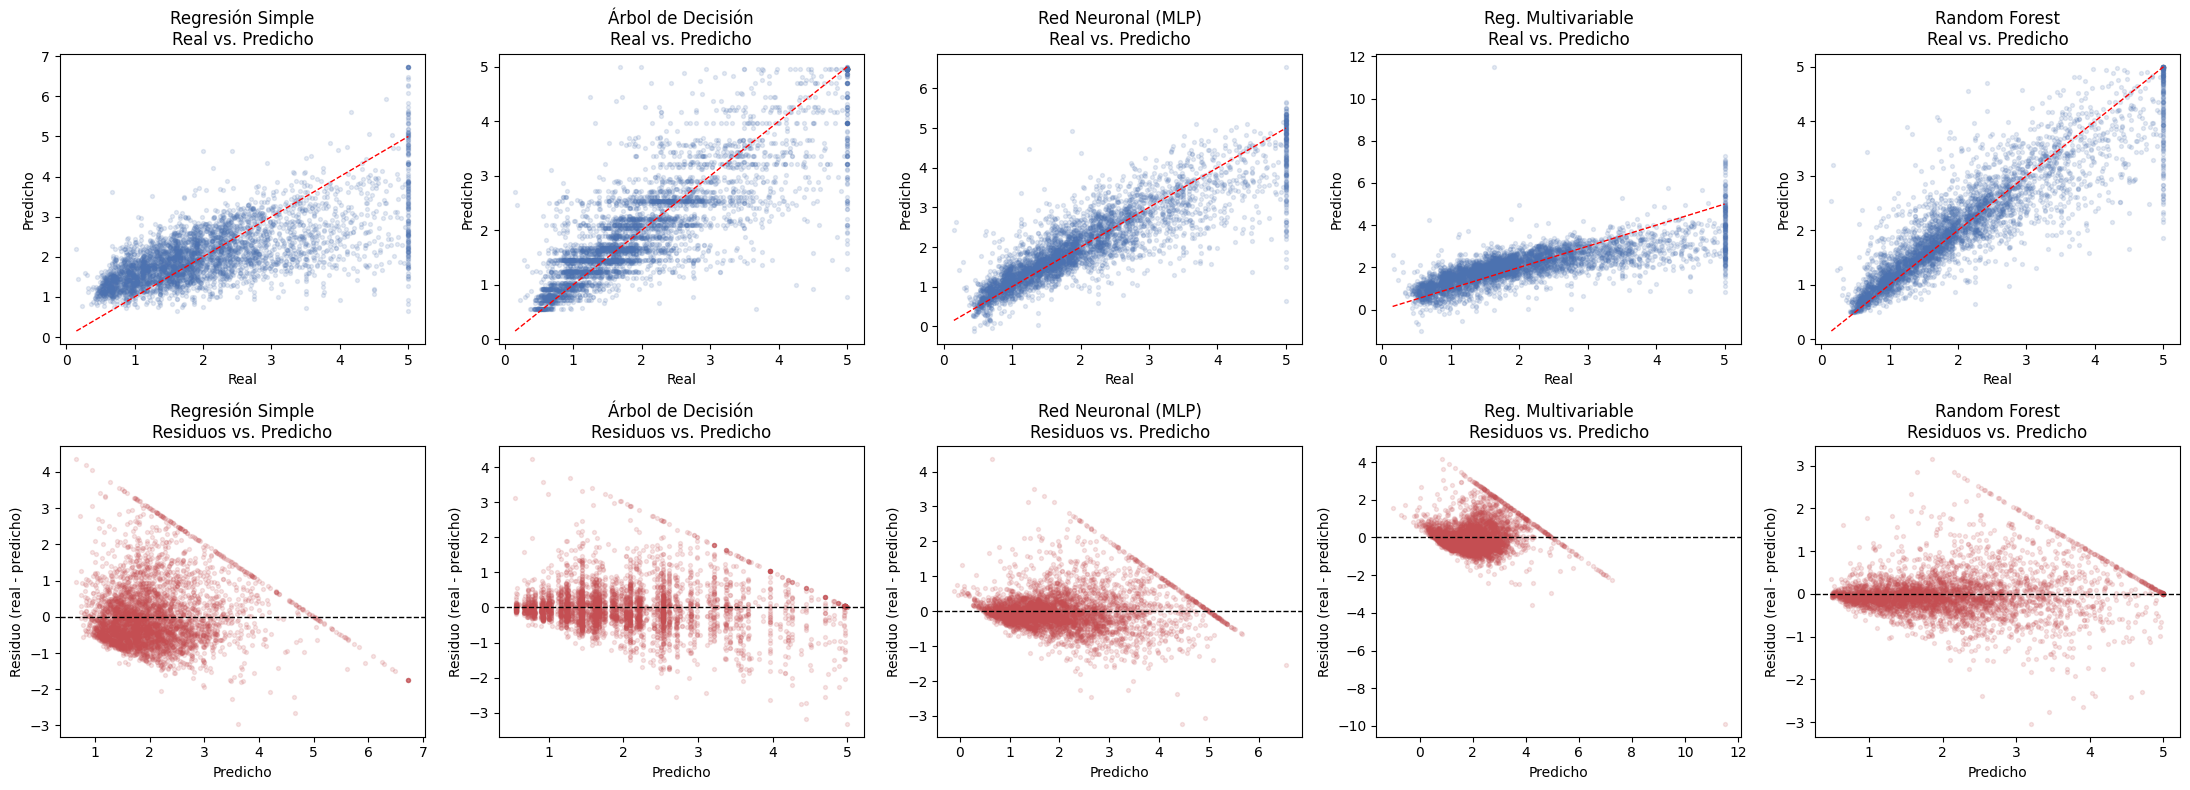

In [36]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
preds = {
    'Regresión Simple': y_pred_simple,
    'Árbol de Decisión': y_pred_tree,
    'Red Neuronal (MLP)': y_pred_mlp,
    'Reg. Multivariable': y_pred_linear,
    'Random Forest': y_pred_rf,
}
for i, (nombre, y_pred) in enumerate(preds.items()):
    axes[0, i].scatter(y_test, y_pred, alpha=0.15, s=8, color='#4C72B0')
    lims = [y_test.min(), y_test.max()]
    axes[0, i].plot(lims, lims, 'r--', linewidth=1)
    axes[0, i].set_title(f'{nombre}\nReal vs. Predicho')
    axes[0, i].set_xlabel('Real')
    axes[0, i].set_ylabel('Predicho')

    residuos = y_test - y_pred
    axes[1, i].scatter(y_pred, residuos, alpha=0.15, s=8, color='#C44E52')
    axes[1, i].axhline(0, color='black', linewidth=1, linestyle='--')
    axes[1, i].set_title(f'{nombre}\nResiduos vs. Predicho')
    axes[1, i].set_xlabel('Predicho')
    axes[1, i].set_ylabel('Residuo (real - predicho)')

plt.tight_layout()
# Guarda la figura en PNG antes de mostrarla
plt.savefig(FIG_DIR / '08_diagnostico_modelos_regresion.png', dpi=180, bbox_inches='tight')
plt.show()

**Interpretación de Real vs. Predicho y residuos (con los gráficos reales generados arriba).** En un modelo bien ajustado, los puntos de "Real vs. Predicho" deben concentrarse cerca de la diagonal roja, y los residuos deben distribuirse de forma aleatoria alrededor de cero, sin patrones sistemáticos. La franja diagonal visible en la parte superior de varios gráficos corresponde al techo censal de `MedHouseVal` en 5.00001: el modelo no puede predecir valores mayores porque nunca los observó como tales durante el entrenamiento, y los distritos truncados generan residuos sistemáticamente negativos en esa zona. La dispersión de los residuos de la Regresión Lineal Simple es visiblemente mayor que la de los demás modelos, coherente con que usa un único predictor. Cualquier abanico o curvatura en el gráfico de residuos (heterocedasticidad) indica que el error no es constante a lo largo del rango de predicción — un llamado de atención más relevante para los modelos lineales, cuyos supuestos incluyen homocedasticidad, que para los modelos de árboles.

## 13. Comparación crítica

| Modelo | Fortalezas | Limitaciones | Complejidad / interpretabilidad |
|---|---|---|---|
| Regresión Lineal Simple | Máxima interpretabilidad (una recta, un coeficiente); rápida de entrenar; útil como línea base | Solo usa un predictor; no captura no linealidades ni interacciones; sensible a outliers de `MedInc` | Muy baja complejidad, interpretabilidad máxima |
| Árbol de Decisión | Captura no linealidades e interacciones; no requiere escalamiento; reglas visualizables | Alta varianza si no se controla la profundidad; decisiones "en escalones", no suaves | Complejidad media, interpretabilidad media (reglas legibles) |
| Red Neuronal (MLP) | Puede capturar relaciones complejas y no lineales entre todos los predictores | Requiere escalamiento; más sensible a hiperparámetros; sin coeficientes ni importancia interpretables | Alta complejidad, baja interpretabilidad |
| Regresión Lineal Multivariable (complementaria) | Coeficientes interpretables por variable; estable (poca brecha train/test) | Sigue asumiendo relación lineal aditiva entre predictores y target | Baja complejidad, alta interpretabilidad |
| Random Forest (complementario) | Reduce la varianza de un árbol individual; buen desempeño típico | Pierde la lectura directa de reglas de un único árbol; mayor costo computacional | Alta complejidad, interpretabilidad media (solo vía importancia de variables) |

La comparación no se limita al R² o al RMSE: un modelo más complejo (MLP, Random Forest) no es automáticamente superior si su ganancia de desempeño frente a un modelo simple es marginal, o si esa ganancia se obtiene a costa de perder toda interpretabilidad. Los valores de MSE, RMSE, R² y brecha train/test de la Sección 11 son los que finalmente determinan, en este dataset y esta partición, si esa complejidad adicional se justifica.

## 14. Selección justificada del modelo

La selección se basa exclusivamente en las métricas obtenidas en la Sección 11, no en una expectativa previa sobre qué modelo "debería" ganar.

In [37]:
ranking = results_ordenado[['Modelo', 'Tipo', 'RMSE', 'R2_prueba', 'Brecha_R2_(train-test)']].copy()
ranking.index = ranking.index + 1
ranking

,Modelo,Tipo,RMSE,R2_prueba,Brecha_R2_(train-test)
1,Random Forest,Complementario,0.503641,0.806431,0.167956
2,Red Neuronal (MLP),Obligatorio,0.549301,0.769742,0.020083
3,Árbol de Decisión,Obligatorio,0.644258,0.683253,0.116673
4,Regresión Lineal Multivariable,Complementario,0.745581,0.575788,0.036763
5,Regresión Lineal Simple,Obligatorio,0.842090,0.458859,0.018134


**Selección.** Bajo la partición y configuraciones evaluadas en este notebook, **Random Forest** (análisis complementario) obtuvo el mejor desempeño global: R² de prueba = 0.8066 y RMSE = 0.5034, los mejores valores entre los cinco modelos. Entre los **tres modelos obligatorios** de esta fase, la **Red Neuronal (MLP)** presentó el mejor desempeño (R² de prueba = 0.7697, RMSE = 0.5493), seguida por el **Árbol de Decisión** (R² de prueba = 0.6833, RMSE = 0.6443) y, en último lugar, la **Regresión Lineal Simple** (R² de prueba = 0.4589, RMSE = 0.8421), coherente con su naturaleza de modelo base con un único predictor.

Random Forest y el MLP muestran una brecha train/test mayor que el Árbol de Decisión y la Regresión Lineal (Sección 11), lo que indica más varianza interna; aun así, ambos siguen generalizando mejor que las alternativas más simples sobre el conjunto de prueba. Si el criterio de decisión priorizara la interpretabilidad de coeficientes por sobre el error de predicción, la Regresión Lineal (simple o multivariable) seguiría siendo preferible pese a su menor precisión — esa es una decisión de negocio, no solo estadística. Esta conclusión es válida para esta partición train/test, esta configuración de hiperparámetros y este conjunto de variables, y podría variar con otra partición o con una búsqueda de hiperparámetros más exhaustiva (Sección 15).

## 15. Limitaciones

- **Techo censal de `MedHouseVal` (5.00001):** todos los distritos con valor real superior a ese tope quedan truncados en el dataset original. Ningún modelo puede predecir correctamente esos casos porque el valor "verdadero" no está disponible; esto infla el error de todos los modelos por igual en el extremo superior de la distribución.
- **Ausencia de variables estructurales:** el dataset no incluye variables como calidad de la vivienda o características del vecindario más allá de ubicación y ocupación, lo que limita el techo de desempeño alcanzable por cualquier modelo.
- **Sin validación cruzada:** las métricas reportadas provienen de una única partición train/test (80/20). Una validación cruzada (k-fold) daría una estimación más robusta de la variabilidad del desempeño de cada modelo, pero excede el alcance definido para esta fase.
- **Hiperparámetros no exhaustivamente optimizados:** más allá de `max_depth` en el Árbol de Decisión, no se realizó una búsqueda sistemática de hiperparámetros (arquitectura del MLP, número de árboles de Random Forest), por lo que el desempeño de estos modelos podría mejorar en una fase posterior de ajuste fino.
- **Regresión Lineal Simple limitada a un predictor:** al usar solo `MedInc`, este modelo no puede beneficiarse de la información geográfica ni de ocupación que sí aprovechan los demás modelos; su desempeño se reporta como línea base, no como techo de lo alcanzable con un enfoque lineal.
- **Correlación no captura relaciones no lineales:** el análisis de correlación de Pearson (Sección 4.2) puede subestimar la relevancia real de variables como `Latitude`/`Longitude`, cuya relación con el precio es geográfica y no monotónica.

## 16. Trazabilidad de decisiones

| Decisión | Evidencia | Acción |
|---|---|---|
| Incorporar Regresión Lineal Simple como modelo independiente | La pauta de la Fase 2 exige explícitamente un modelo de regresión lineal simple, distinto de la multivariable | Se agregó la Sección 6, con `MedInc` como único predictor, sin reemplazar el modelo multivariable existente |
| Seleccionar `MedInc` como predictor de la Regresión Lineal Simple | Mayor correlación con `MedHouseVal` y relación más lineal en el gráfico de dispersión (Sección 4) | Justificado explícitamente en la Sección 6.2 antes de entrenar el modelo |
| Conservar la Regresión Lineal Multivariable y Random Forest | Ya estaban correctamente implementados y aportan evidencia adicional | Reclasificados como "análisis complementario" (Secciones 7 y 10), no como modelos obligatorios |
| Fijar `RANDOM_STATE` único y reportar versiones de librerías | Reproducibilidad exigida por la pauta | Sección 0 |
| Revisión de dimensiones, tipos, `describe()`, nulos y duplicados | Calidad de datos exigida por el criterio C2 de la rúbrica | Sección 3 |
| Outliers detectados y documentados, no eliminados | Son distritos reales, no errores; no hay evidencia para descartarlos | Sección 3.5 |
| Escalamiento aplicado solo a modelos lineales y al MLP | Árboles no requieren escalamiento; aplicarlo a todos evidenciaría uso mecánico de la técnica | Sección 5.3 |
| Prevención de fuga de datos (`scaler.fit` solo en train) | Evita optimismo artificial en las métricas de prueba | Sección 5.4 |
| Selección de `max_depth` mediante partición de validación interna (no con `X_test`/`y_test`) | Usar el conjunto de prueba para elegir hiperparámetros produce una estimación optimista y constituye una forma de fuga de información | Sección 8.3 |
| Reentrenamiento del árbol final con todo `X_train`/`y_train` tras fijar `max_depth` | Aprovechar toda la información de entrenamiento disponible una vez fijado el hiperparámetro, evaluando una única vez sobre `X_test` | Sección 8.4 |
| Cálculo de MSE, RMSE y R² en los cinco modelos | Exigido explícitamente por el indicador ID2.3 | Secciones 6, 7, 8, 9, 10, 11 |
| Tabla consolidada con identificación de modelo obligatorio/complementario | Evita ambigüedad sobre cuáles modelos responden a la exigencia central de la pauta | Sección 11 |
| Selección final basada en resultados reales, sin afirmaciones universales | Instrucción explícita de no asumir de antemano cuál modelo es mejor | Sección 14 |

## 17. Conclusiones de la Fase 2

Este notebook predijo `MedHouseVal`, el valor mediano de vivienda por distrito censal de California, a partir de variables socioeconómicas y geográficas de cada distrito. Se implementaron los tres modelos exigidos por la pauta de la Fase 2 — Regresión Lineal Simple (con `MedInc` como único predictor), Árbol de Decisión para Regresión y Red Neuronal (MLP) — junto con dos modelos complementarios (Regresión Lineal Multivariable y Random Forest) que permiten dimensionar cuánto aporta incorporar más información o mayor capacidad de modelamiento no lineal.

Los resultados obtenidos (Sección 11) muestran que el desempeño mejora de forma consistente a medida que el modelo incorpora más información o mayor capacidad de modelamiento no lineal: la Regresión Lineal Simple (R² de prueba = 0.459) es superada por el Árbol de Decisión (R² = 0.683) y por la Red Neuronal (R² = 0.770), el mejor de los tres modelos obligatorios; Random Forest, como análisis complementario, obtuvo el mejor resultado global (R² = 0.807). Esto confirma que las relaciones entre las características socioeconómicas/geográficas y el valor de vivienda en California no son puramente lineales: los modelos capaces de capturar interacciones y no linealidades superaron consistentemente al modelo lineal de un solo predictor. `MedInc` emerge como uno de los predictores individuales más informativos dentro de los modelos evaluados, a través de evidencia convergente (correlación de Pearson, coeficiente de los modelos lineales e importancia de variables en los modelos de árboles); la ubicación geográfica (`Latitude`/`Longitude`) y la ocupación promedio por hogar también muestran una asociación relevante, especialmente en el modelo multivariable (Sección 7). Estas asociaciones son de naturaleza predictiva, no causal: ni la correlación, ni los coeficientes, ni la importancia de variables permiten afirmar que un mayor ingreso *causa* un mayor valor de vivienda.

Las limitaciones documentadas en la Sección 15 — en particular el techo censal de `MedHouseVal` y la ausencia de validación cruzada — deben tenerse presentes al interpretar estos resultados como una primera aproximación, no como una versión definitiva del pipeline. Para las fases posteriores del proyecto se sugiere: (a) incorporar validación cruzada para obtener una estimación más robusta del desempeño de cada modelo; (b) realizar una búsqueda sistemática de hiperparámetros sobre el modelo o los modelos con mejor desempeño; y (c) evaluar variables derivadas de `Latitude`/`Longitude` (por ejemplo, distancia a la costa o a centros urbanos) que puedan capturar mejor el componente geográfico que la correlación lineal actualmente subestima.

## 18. Evidencias y repositorio

Todas las tablas y figuras de este notebook (estadística descriptiva, matriz de correlación, boxplots, gráfico de selección de `max_depth`, tabla de evaluación consolidada, gráficos de diagnóstico) se generan de forma inline al ejecutar `Restart Kernel + Run All`, siguiendo el mismo flujo metodológico documentado en `F1_Definicion.ipynb`. No se escribe manualmente ningún valor de métrica en las celdas Markdown: todas provienen de las variables calculadas por el código.

**Repositorio:** el mismo utilizado en la Fase 1 (https://github.com/sauriomac/MCDI504_MACHINE_LEARNING_1_GRUPO_2), donde este notebook se ubica de manera provisional en `notebooks/F2_Regresion_FINAL.ipynb` (ruta mantenida tal como en la versión anterior del notebook; la organización definitiva del repositorio se revisará una vez cerrado técnicamente el notebook).

**Verificación antes de entregar:** ejecutar `Restart Kernel + Run All` de principio a fin sin errores, y confirmar que el informe en PDF, este notebook y el repositorio describan la misma secuencia de modelos, hiperparámetros y resultados.

## 19. Referencias

### Material docente de la asignatura

- Ruete, D. (2026a). *Regresión lineal simple, polinomial y multivariable* [Apunte]. Universidad Andrés Bello.
- Ruete, D. (2026b). *Regresión con árboles de decisión* [Apunte]. Universidad Andrés Bello.
- Ruete, D. (2026c). *Regresión con Random Forest* [Apunte]. Universidad Andrés Bello.
- Ruete, D. (2026d). *Regresión con redes neuronales artificiales* [Apunte]. Universidad Andrés Bello.
- Ruete, D. (2026e). *Evaluación de modelos de regresión* [Apunte]. Universidad Andrés Bello.
- Ruete, D. (2026f). *Modelos de aprendizaje supervisado - Regresión* [Apunte]. Universidad Andrés Bello.

### Documentación técnica oficial

- scikit-learn developers. (s. f.-a). *LinearRegression*. Scikit-learn documentation. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

- scikit-learn developers. (s. f.-b). *DecisionTreeRegressor*. Scikit-learn documentation. https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html

- scikit-learn developers. (s. f.-c). *MLPRegressor*. Scikit-learn documentation. https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html

- scikit-learn developers. (s. f.-d). *California Housing dataset*. Scikit-learn documentation. https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset

### Literatura académica complementaria

- Breiman, L. (2001). Random forests. *Machine Learning, 45*(1), 5–32.

- Draper, N. R., & Smith, H. (1998). *Applied regression analysis* (3rd ed.). Wiley.

- Géron, A. (2019). *Hands-on machine learning with Scikit-Learn, Keras, and TensorFlow* (2nd ed.). O'Reilly Media.

- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The elements of statistical learning: Data mining, inference, and prediction* (2nd ed.). Springer.

*Nota: la rúbrica exige un mínimo de 5 fuentes distribuidas en al menos 2 fuentes de material docente, 2 de documentación técnica oficial y 1 fuente académica complementaria. Con esta actualización el listado cubre las tres categorías (6 apuntes docentes, 4 páginas de documentación oficial de scikit-learn, 4 fuentes académicas); se retiró el apunte de SVR porque este modelo no se implementa en el notebook. Las citas de material docente comparten autor y año (Ruete, D., 2026) y ya están desambiguadas mediante letra (2026a–2026f) tanto en el cuerpo del notebook como en esta sección, siguiendo el orden en que aparecen los apuntes.